In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [ ]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [ ]:
print(trades.shape)
print(sentiment.shape)

trades.head()

(211224, 16)
(2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
trades['time'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M")

trades['date'] = trades['time'].dt.date

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

sentiment['date'] = sentiment['date'].dt.date

In [ ]:
merged = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [ ]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed


In [ ]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


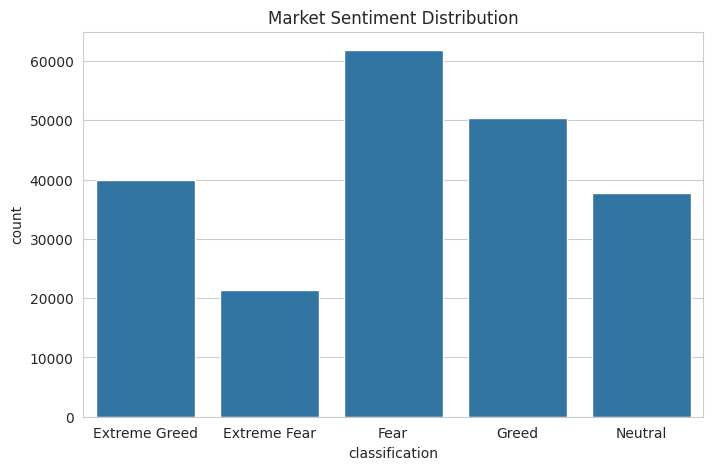

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.title("Market Sentiment Distribution")
plt.show()

In [ ]:
merged['Closed PnL']

,Closed PnL
0,0.0000
1,0.0000
2,0.0000
3,0.0000
4,0.0000
...,...
211219,-20.2566
211220,-112.5773
211221,-22.4402
211222,-190.7894


In [ ]:
sentiment_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(sentiment_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


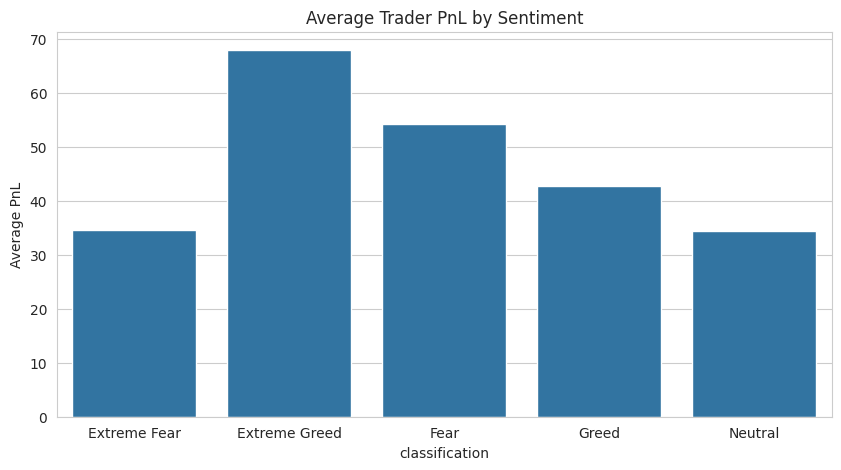

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=sentiment_pnl.index,
    y=sentiment_pnl.values
)

plt.title("Average Trader PnL by Sentiment")
plt.ylabel("Average PnL")

plt.show()

In [ ]:
merged['is_profit'] = merged['Closed PnL'] > 0

In [ ]:
profit_rate = merged.groupby(
    'classification'
)['is_profit'].mean()*100

print(profit_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


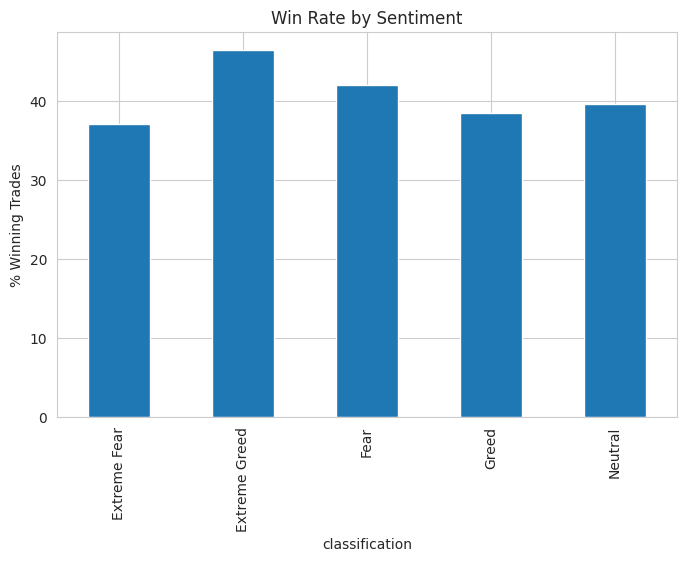

In [ ]:
profit_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Win Rate by Sentiment")
plt.ylabel("% Winning Trades")
plt.show()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


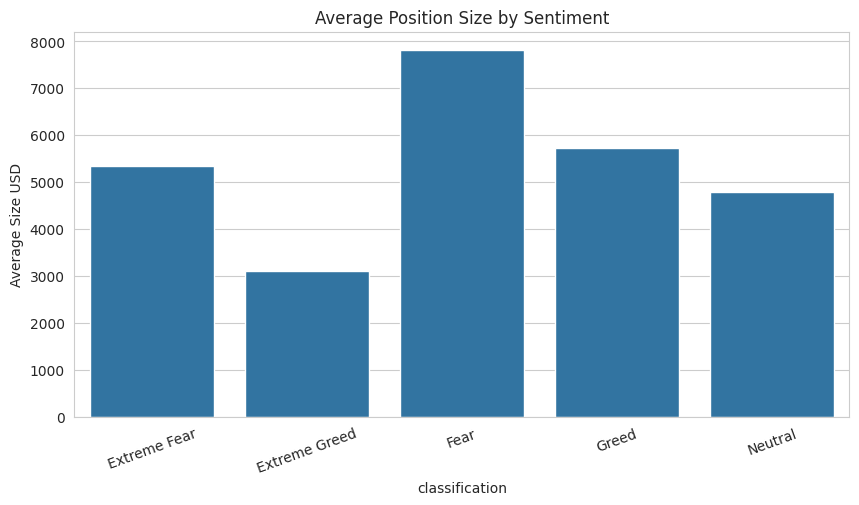

In [ ]:
position_size = merged.groupby(
    'classification'
)['Size USD'].mean()

print(position_size)

plt.figure(figsize=(10,5))

sns.barplot(
    x=position_size.index,
    y=position_size.values
)

plt.title("Average Position Size by Sentiment")
plt.ylabel("Average Size USD")
plt.xticks(rotation=20)

plt.show()

In [ ]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'time', 'date', 'classification', 'is_profit'],
      dtype='object')


In [ ]:
pd.crosstab(
    merged['classification'],
    merged['Side']
)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


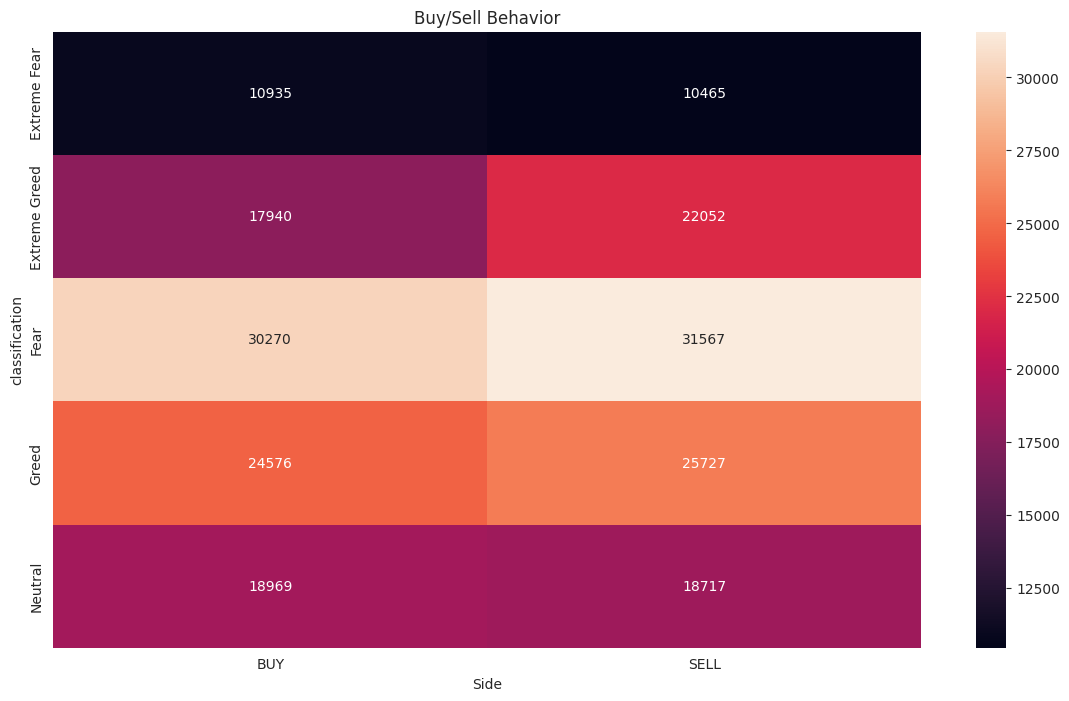

In [ ]:
table = pd.crosstab(
    merged['classification'],
    merged['Side']
)

sns.heatmap(
    table,
    annot=True,
    fmt='d'
)

plt.title("Buy/Sell Behavior")
plt.show()

In [ ]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum()

top_traders = top_traders.sort_values(
    ascending=False
).head(20)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    2.205191e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d    1.265789e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.

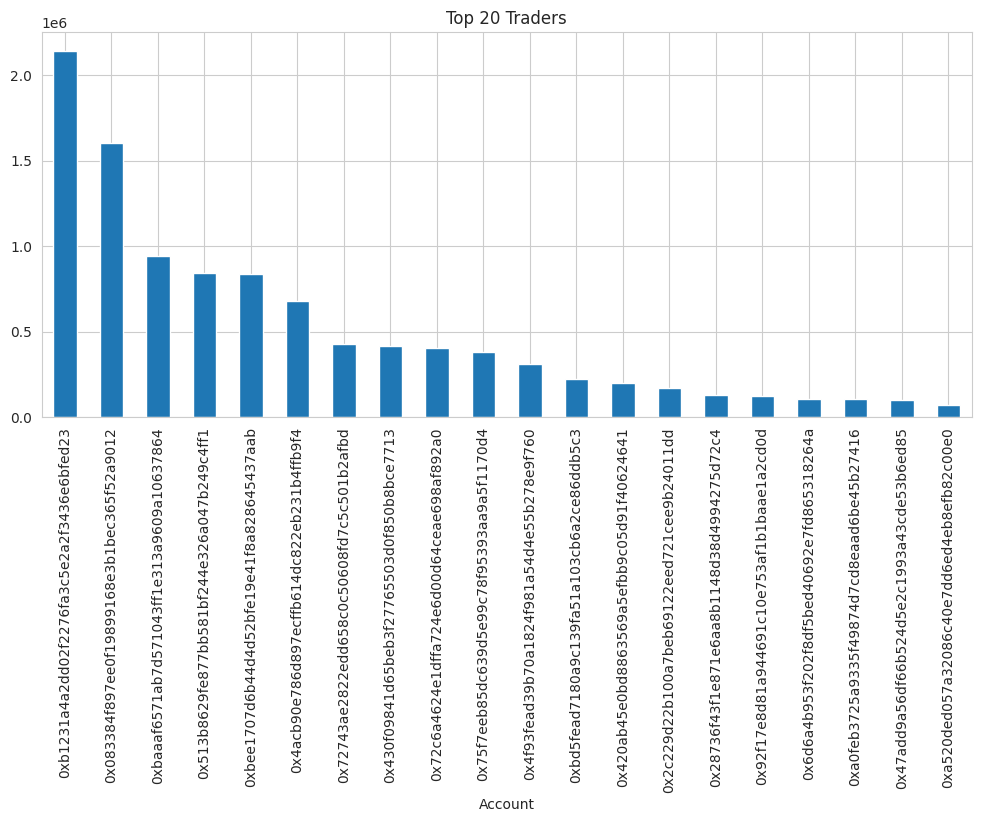

In [ ]:
top_traders.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 20 Traders")
plt.show()

In [ ]:
fear = merged[
    merged['classification'].str.contains(
        'Fear',
        na=False
    )
]['Closed PnL']

greed = merged[
    merged['classification'].str.contains(
        'Greed',
        na=False
    )
]['Closed PnL']

In [ ]:
t_stat,p_value = ttest_ind(
    fear,
    greed,
    nan_policy='omit'
)

print("P-value =",p_value)

P-value = 0.3231167085211579


In [ ]:
sentiment_map = {
    'Extreme Fear':1,
    'Fear':2,
    'Neutral':3,
    'Greed':4,
    'Extreme Greed':5
}

merged['sentiment_score'] = merged['classification'].map(sentiment_map)

corr = merged['sentiment_score'].corr(
    merged['Closed PnL']
)

print("Correlation:", corr)

Correlation: 0.005969909479052145


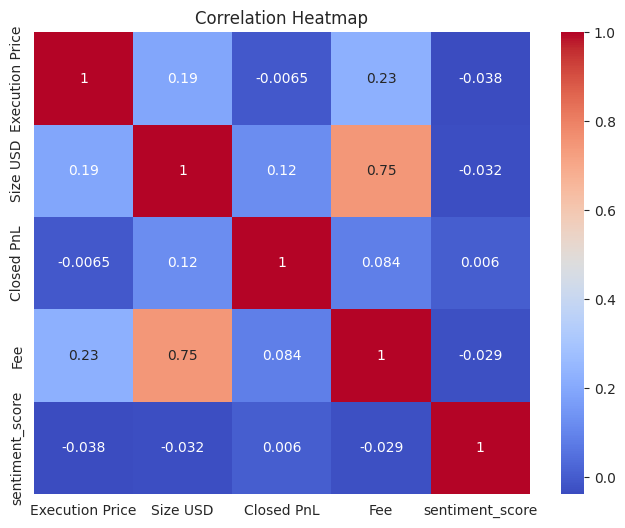

In [ ]:
numeric_cols = [
    'Execution Price',
    'Size USD',
    'Closed PnL',
    'Fee',
    'sentiment_score'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    merged[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
trader_pnl = merged.groupby(
    'Account'
)['Closed PnL'].sum()

top_10 = trader_pnl.quantile(0.90)
bottom_10 = trader_pnl.quantile(0.10)

merged['Trader Group'] = merged['Account'].map(
    lambda x:
    'Top Trader'
    if trader_pnl[x] >= top_10
    else (
        'Bottom Trader'
        if trader_pnl[x] <= bottom_10
        else 'Average Trader'
    )
)

segment_analysis = merged.groupby(
    ['Trader Group','classification']
)['Closed PnL'].mean().reset_index()

print(segment_analysis)

      Trader Group classification  Closed PnL
0   Average Trader   Extreme Fear   40.296303
1   Average Trader  Extreme Greed   44.076218
2   Average Trader           Fear   27.839546
3   Average Trader          Greed   42.533188
4   Average Trader        Neutral   11.480092
5    Bottom Trader   Extreme Fear  -35.928972
6    Bottom Trader  Extreme Greed   74.025893
7    Bottom Trader           Fear   44.125956
8    Bottom Trader          Greed -192.138225
9    Bottom Trader        Neutral   20.700790
10      Top Trader   Extreme Fear   57.389282
11      Top Trader  Extreme Greed  378.876743
12      Top Trader           Fear   94.589772
13      Top Trader          Greed  101.051141
14      Top Trader        Neutral   90.544663


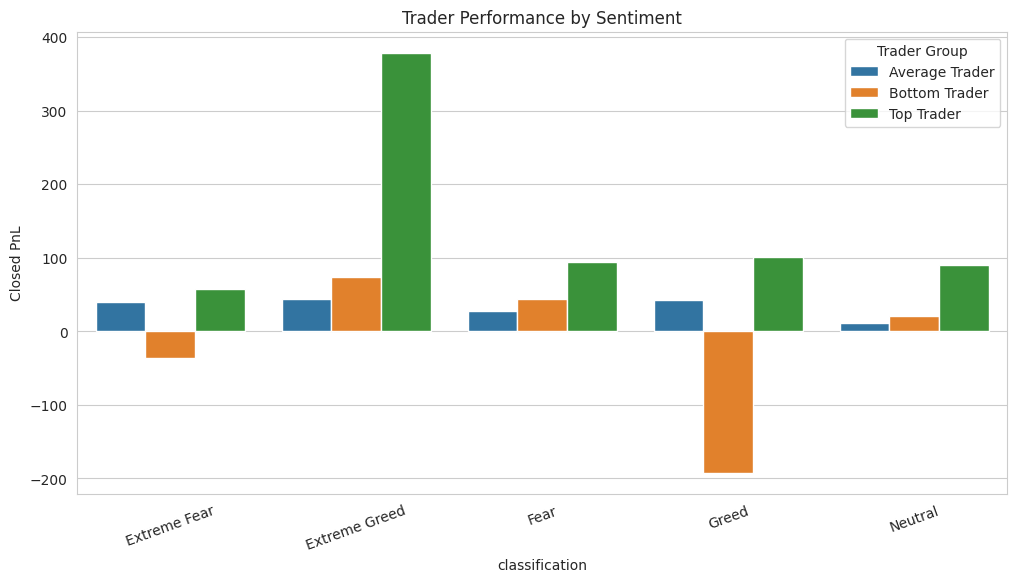

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=segment_analysis,
    x='classification',
    y='Closed PnL',
    hue='Trader Group'
)

plt.title("Trader Performance by Sentiment")

plt.xticks(rotation=20)

plt.show()

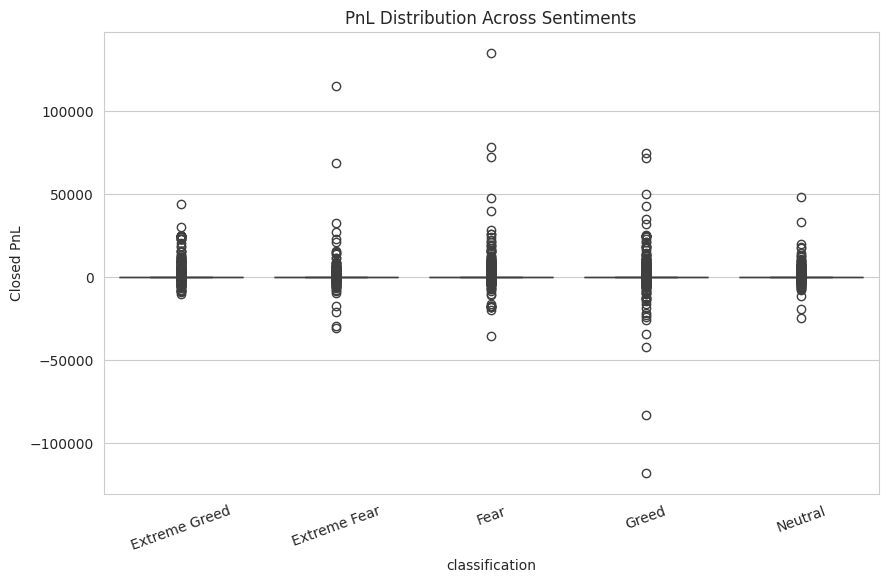

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution Across Sentiments")

plt.xticks(rotation=20)

plt.show()

In [ ]:
daily = merged.groupby(
    ['date','classification']
)['Closed PnL'].mean().reset_index()

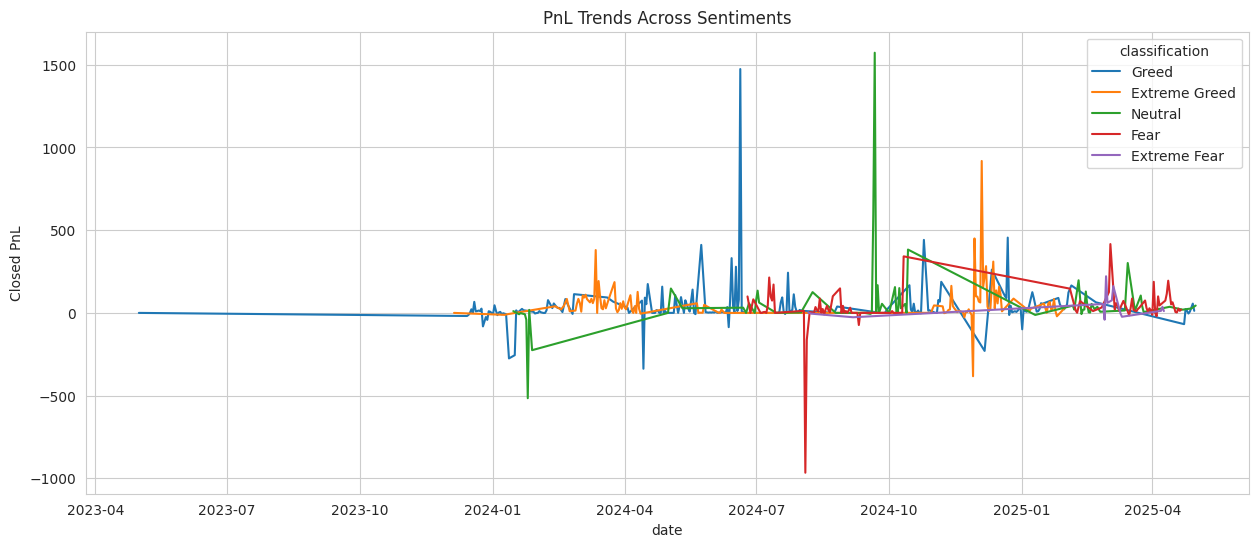

In [ ]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=daily,
    x='date',
    y='Closed PnL',
    hue='classification'
)

plt.title("PnL Trends Across Sentiments")
plt.show()

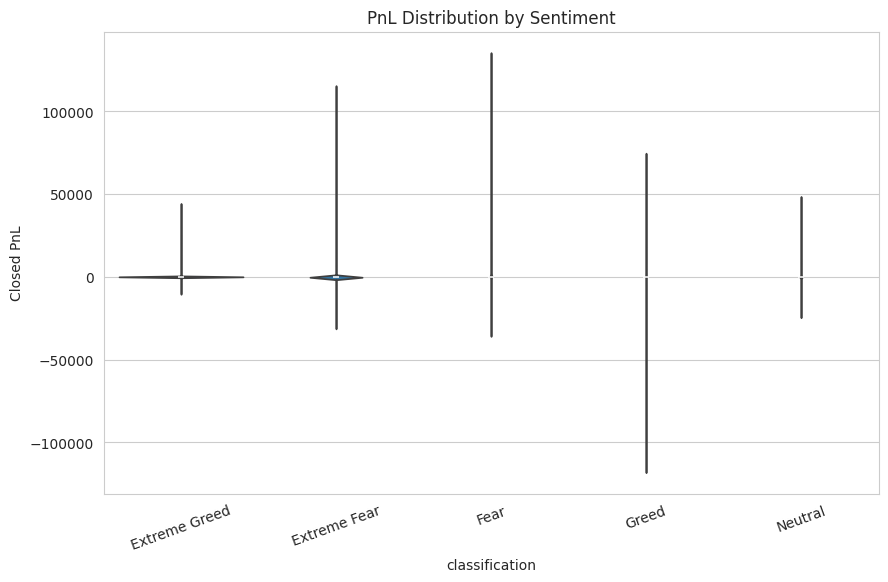

In [ ]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=20)

plt.show()

# Key Findings

1. Extreme Greed sentiment produced the highest average PnL (67.89), indicating strong profitability during highly optimistic market conditions.

2. Extreme Greed also achieved the highest winning trade percentage (46.49%).

3. Fear sentiment generated higher average profits than Greed sentiment, suggesting potential opportunities during market uncertainty.

4. Sentiment score and Closed PnL showed very weak correlation (0.006), indicating sentiment alone does not determine profitability.

5. Top traders significantly outperformed average and bottom traders across all sentiment categories.

6. Top traders achieved exceptionally high profitability during Extreme Greed periods (378.88 average PnL).

7. Position sizes were largest during Fear periods, indicating increased trader activity during uncertain markets.

# Trading Recommendations

- Increase exposure during Extreme Greed only with proper risk management.
- Monitor Fear periods for contrarian trading opportunities.
- Follow behavior patterns of consistently profitable traders.
- Combine sentiment indicators with technical analysis rather than using sentiment alone.